This notebook will compare the segment probabilities between the detailed and reduced models. Expectation is that the reduced model will have less probability distally, as those segments have been merged resulting in less length.


Note: The "segment probability" is the probability of a synpase being on that synapse during random choice. This probability is the length of the segment relative to total length.

In [1]:
import sys
sys.path.append('..')
sys.path.append('../Modules')

from Modules import analysis
import pandas as pd
import os

In [2]:
simulations_to_compare = {
    "Detailed": {
        "dir": "/home/drfrbc/Neural-Modeling/scripts/2025-03-14-08-52-all3_stas_multiple_seeds/sta_Complex_Np5000",
        "color": "blue"
    },
    "Reduced": {
        "dir": "/home/drfrbc/Neural-Modeling/scripts/2025-03-14-08-52-all3_stas_multiple_seeds/sta_ReduceBranches_Np5000",
        "color": "red"
    }
}

In [3]:
for sim in simulations_to_compare.keys():
    simulations_to_compare[sim]["params"] = analysis.DataReader.load_parameters(simulations_to_compare[sim]["dir"])
    simulations_to_compare[sim]["segs"] = pd.read_csv(os.path.join(simulations_to_compare[sim]["dir"], "segment_data.csv"))
    simulations_to_compare[sim]["transfer_impedance"] = pd.read_csv(os.path.join(simulations_to_compare[sim]["dir"], "elec_distance_soma.csv"))

--No graphics will be displayed.


In [4]:
import numpy as np
import matplotlib.pyplot as plt


def compute_total_segment_length_per_bin(transfer_impedances, segment_lengths, bins=30):
    """
    Bins the transfer impedance values and sums segment lengths within each bin.
    
    Args:
        transfer_impedances (list or array): Transfer impedance values.
        segment_lengths (list or array): Corresponding segment lengths.
        bins (int or array): Number of bins or bin edges.

    Returns:
        bin_centers (array): Center of each bin.
        total_lengths (array): Total segment length in each bin.
    """
    bin_edges = np.linspace(min(transfer_impedances), max(transfer_impedances), bins + 1)
    bin_indices = np.digitize(transfer_impedances, bin_edges) - 1  # Get bin index for each value
    
    total_lengths = np.zeros(bins)
    
    for i in range(len(transfer_impedances)):
        bin_idx = bin_indices[i]
        if 0 <= bin_idx < bins:  # Ensure within range
            total_lengths[bin_idx] += segment_lengths[i]
    
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Compute bin centers
    return bin_centers, total_lengths


def plot_total_segment_length_vs_transfer_impedance():
    """
    Plots the total segment length as a function of binned transfer impedance.
    """
    fig, ax = plt.subplots()

    for sim in simulations_to_compare.keys():
        transfer_impedances = simulations_to_compare[sim]['transfer_impedance']['theta_active']
        segment_lengths = simulations_to_compare[sim]["segs"]["L"]

        # Compute total segment length per bin
        bin_centers, total_lengths = compute_total_segment_length_per_bin(transfer_impedances, segment_lengths, bins=50)

        ax.plot(bin_centers, total_lengths, color=simulations_to_compare[sim]["color"], label=sim)

    ax.set_xlabel("Input Transfer impedance ratio (Ohm)")
    ax.set_ylabel("Total Segment Length (m)")
    ax.legend()
    plt.show()

def plot_seg_probs_vs_transfer_impedance():
    """
    Plots the proprotional total segment length as a function of binned transfer impedance.
    """
    fig, ax = plt.subplots()

    for sim in simulations_to_compare.keys():
        transfer_impedances = simulations_to_compare[sim]['transfer_impedance']['theta_active']
        segment_lengths = simulations_to_compare[sim]["segs"]["L"]

        all_cell_total_length = sum(simulations_to_compare[sim]["segs"]["L"])
        segment_probs = segment_lengths / all_cell_total_length

        # Compute total segment length per bin
        bin_centers, total_lengths = compute_total_segment_length_per_bin(transfer_impedances, segment_probs, bins=50)

        ax.plot(bin_centers, total_lengths, color=simulations_to_compare[sim]["color"], label=sim)

    ax.set_xlabel("Input Transfer impedance ratio")
    ax.set_ylabel("Segment Probability")
    ax.legend()
    plt.show()

In [ ]:
# total length
# sum(simulations_to_compare["Detailed"]["segs"]["L"])

12657.56734731988

In [ ]:
# list of impedance ratios by segment
# simulations_to_compare["Detailed"]['transfer_impedance']['theta_active']

0       1.000000
1       0.931647
2       0.859303
3       0.797237
4       0.743420
          ...   
2506    0.188340
2507    0.176287
2508    0.791953
2509    0.557984
2510    0.430192
Name: theta_active, Length: 2511, dtype: float64

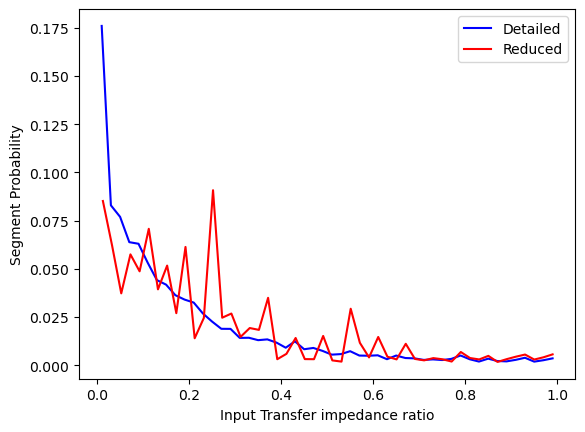

In [7]:
# plot segment length as a function of transfer impedance from the soma for each simulation
# plot_segment_length_as_function_of_transfer_impedance()
# plot_total_segment_length_vs_transfer_impedance()
plot_seg_probs_vs_transfer_impedance()

In [ ]:
# getting these indices to highlight them in plot_reduction_morphology.ipynb
def get_seg_indice_for_imp_range(imp_ratio_range):
    reduced_inds = np.where((simulations_to_compare["Reduced"]["transfer_impedance"]["theta_active"] > imp_ratio_range[0]) & (simulations_to_compare["Reduced"]["transfer_impedance"]["theta_active"] < imp_ratio_range[1]))[0]
    # print(f"reduced_inds: {reduced_inds}")

    detailed_inds = np.where((simulations_to_compare["Detailed"]["transfer_impedance"]["theta_active"] > imp_ratio_range[0]) & (simulations_to_compare["Detailed"]["transfer_impedance"]["theta_active"] < imp_ratio_range[1]))[0]
    # print(f"detailed_inds: {detailed_inds}")
    return reduced_inds, detailed_inds

reduced_inds, detailed_inds = get_seg_indice_for_imp_range((0.225, 0.3))
reduced_inds, detailed_inds = get_seg_indice_for_imp_range((0, 0.1))
detailed_inds

reduced_inds: [ 39  40  41  42  43 203 216 244 249 254 260 263 267 269 270 271 276 279
 284 286 291 296 302]
detailed_inds: [  12   13   14   44   45   46   63   64   65  104  134  138  139  159
  188  189  190  218  236  237  241  246  272  273  274  285  286  287
  288  289  290  291  325  326  327  368  369  370  390  391  392  421
  422  423  470  471  472  473  474  475  494  513  514  534  535  536
  537  538  539  573  590  612  627  628  629  656  657  658  659  660
  661  692  693  694  695  696  697  715  749  750  751  778  802  803
  804  874  875  876  916  917  938  939  940  977 1068 1069 1070 1078
 1079 1114 1115 1116 1117 1118 1133 1134 1157 1158 1159 1160 1161 1202
 1203 1237 1238 1265 1266 1267 1268 1304 1305 1306 1307 1321 1322 1323
 1333 1370 1371 1408 1409 1410 1479 1480 1481 1482 1483 1484 1485 1486
 1487 1488 1682 1683 1684 1685 1686 1687 1688 1689 1690 1691 1692 2197
 2198 2199 2200 2201 2219 2220 2221 2222 2223 2259 2285 2286 2287 2288
 2289 2290 2313 2314 232

array([  29,   30,   31, ..., 2445, 2446, 2447])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compute_bin_probs(transfer_impedances, segment_lengths, num_bins=50):
    """
    Bins the segments by transfer impedance and computes the probability mass
    in each bin. Returns (bin_centers, bin_probs).
    
    Args:
        transfer_impedances (1D array): Transfer impedance for each segment.
        segment_lengths (1D array): Segment length for each segment.
        num_bins (int): Number of bins.

    Returns:
        bin_centers (1D array): The center of each bin (length = num_bins).
        bin_probs   (1D array): Probability mass in each bin (also length = num_bins),
                                which sums to 1.0.
    """
    total_length = np.sum(segment_lengths)
    if total_length <= 0:
        raise ValueError("Total segment length is zero or negative; cannot compute probabilities.")

    # Each segment’s share of the total
    seg_probs = segment_lengths / total_length

    # Define bin edges and digitize
    t_min, t_max = np.min(transfer_impedances), np.max(transfer_impedances)
    bin_edges = np.linspace(t_min, t_max, num_bins + 1)
    bin_indices = np.digitize(transfer_impedances, bin_edges) - 1

    bin_probs = np.zeros(num_bins, dtype=float)
    for idx, p in zip(bin_indices, seg_probs):
        if 0 <= idx < num_bins:
            bin_probs[idx] += p

    # Compute bin centers
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    return bin_centers, bin_probs

def map_segments_to_detailed_distribution(
    reduced_transfer_impedances,     # T.I. for each Reduced segment
    detailed_bin_centers,            # from compute_bin_probs for Detailed
    detailed_bin_probs               # also from compute_bin_probs
):
    """
    Assign each Reduced segment a probability so that, if we bin them by T.I.,
    we match the Detailed bin probabilities.

    Returns:
        reduced_seg_probs (1D array): Probability for each Reduced segment.
                                      Sum(reduced_seg_probs) = 1.0.
    """
    n_segments = len(reduced_transfer_impedances)
    n_bins = len(detailed_bin_centers)

    # 1) For each Reduced segment, find the nearest Detailed bin
    # assign each Reduced segment to the nearest Detailed bin
    assignments = np.zeros(n_segments, dtype=int)
    for i, ti in enumerate(reduced_transfer_impedances):
        # nearest bin index
        k = np.argmin(np.abs(detailed_bin_centers - ti))
        assignments[i] = k

    # 2) Count how many Reduced segments got assigned to each bin
    # determine the number of segments assigned to each bin
    bin_counts = np.zeros(n_bins, dtype=int)
    for k in assignments:
        bin_counts[k] += 1

    # 3) Assign each segment a fraction of that bin’s Detailed probability
    # distribute probability of each bin equally among its assigned segments
    reduced_seg_probs = np.zeros(n_segments, dtype=float)
    for i, k in enumerate(assignments):
        count_k = bin_counts[k]
        if count_k > 0:
            # The bin’s probability mass is split equally among its assigned segments
            reduced_seg_probs[i] = detailed_bin_probs[k] / count_k

    return reduced_seg_probs

def plot_new_reduced_distribution(simulations_to_compare, num_bins=50):
    """
    1) Bins the Detailed simulation to get a probability distribution.
    2) Assigns new probabilities to each Reduced segment so they match that distribution.
    3) Bins those new Reduced probabilities and plots them over the same bins.
    """
    # --- (A) Detailed distribution ---
    det_ti = simulations_to_compare["Detailed"]["transfer_impedance"]["theta_active"]
    det_len = simulations_to_compare["Detailed"]["segs"]["L"]
    det_bin_centers, det_bin_probs = compute_bin_probs(det_ti, det_len, num_bins)

    # --- (B) Map Reduced segments to the Detailed distribution ---
    red_ti = simulations_to_compare["Reduced"]["transfer_impedance"]["theta_active"]
    new_reduced_seg_probs = map_segments_to_detailed_distribution(
        reduced_transfer_impedances=red_ti,
        detailed_bin_centers=det_bin_centers,
        detailed_bin_probs=det_bin_probs
    )

    # --- (C) Bin the new Reduced probabilities ---
    # We’ll reuse the same bin edges from the Detailed distribution
    bin_edges = np.linspace(np.min(det_ti), np.max(det_ti), num_bins + 1)
    bin_indices = np.digitize(red_ti, bin_edges) - 1

    # Accumulate new_reduced_seg_probs in each bin
    new_bin_probs = np.zeros(num_bins, dtype=float)
    for idx, p in zip(bin_indices, new_reduced_seg_probs):
        if 0 <= idx < num_bins:
            new_bin_probs[idx] += p

    # The bin centers are the same as for Detailed
    red_bin_centers = det_bin_centers

    # --- (D) Plot ---
    plt.figure(figsize=(6,4))
    plt.plot(det_bin_centers, det_bin_probs, label="Detailed", color="blue")
    plt.plot(red_bin_centers, new_bin_probs, label="Reduced", color="red")
    plt.xlabel("Transfer Impedance Ratio")
    plt.ylabel("Probability")
    plt.legend()
    plt.title("Fitting Reduced Probabilities to Detailed")
    plt.show()

    return new_reduced_seg_probs


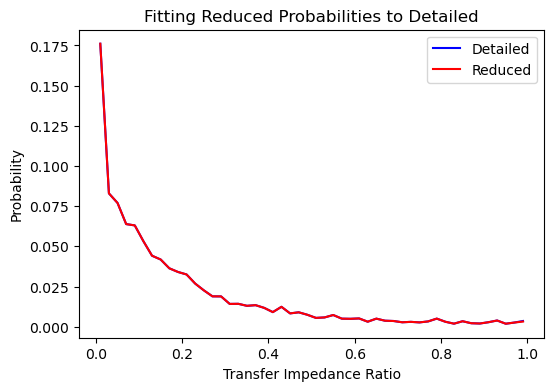

In [9]:
new_reduced_probs = plot_new_reduced_distribution(simulations_to_compare, num_bins=50)

In [10]:
# reduced seg probs
simulations_to_compare["Reduced"]["segs"]["original_probs"] = simulations_to_compare["Reduced"]["segs"]["L"] / sum(simulations_to_compare["Reduced"]["segs"]["L"])
simulations_to_compare["Reduced"]["segs"]["new_probs"] = new_reduced_probs

In [12]:
len(new_reduced_probs)

307

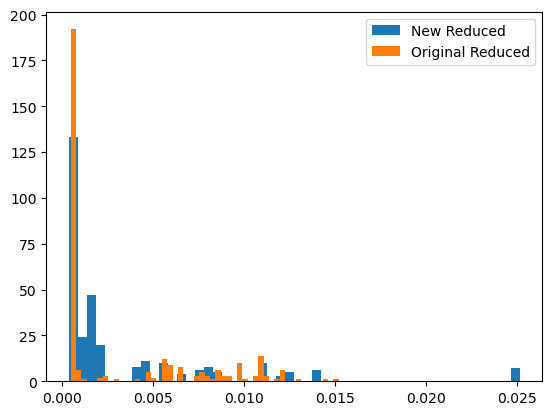

In [13]:
plt.hist(new_reduced_probs, bins=50, label="New Reduced")
plt.hist(simulations_to_compare["Reduced"]["segs"]["original_probs"], bins=50, label="Original Reduced")
plt.legend()
plt.show()